<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/ExamPrep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install chromadb openai pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6

In [ ]:
# 1. Find a nice PDF
# 2. Extract text from the PDF(algorithm***, OCR, hybrid)
# 3. Split, Chunk & Embed (split or chunck by characters, by words, by paragraphs, by sentences)
# 4. function: retrieve_information (CAG, RAG, hybrid)
# 5. ask_ai(text, image, audio)

In [89]:
import base64
import json

from IPython.display import Audio, Image

from chromadb import PersistentClient
from google.colab import userdata
from openai import OpenAI
from openai.types.responses import Response
from typing import List, Literal
from pathlib import Path
from pydantic import BaseModel, Field
from pypdf import PdfReader

In [44]:
openai_api_key = userdata.get('OPENAI_API_KEY')
openai_client = OpenAI(api_key = openai_api_key)

chroma_client = PersistentClient("/content/chromadb")

# Two ways:
# 1. get_or_create_collection (ensure)
# 2. delete_collection + create_collection
chroma_collection = chroma_client.get_or_create_collection("final_project")

In [9]:
def extract_text(path_to_pdf: Path) -> str:
    with PdfReader(path_to_pdf) as pdf_reader:
        return "\n".join(pdf_page.extract_text() for pdf_page in pdf_reader.pages)

In [23]:
# TODO: Potentially extend with chunk by words/sentences.
def chunk_by_length(text: str, length: int = 1000, overlap: int = 300) -> List[str]:
    result = []
    index = 0

    # | ----- A ----- | A-B | ----- B ----- |  B-C | ----- C ---- | ...

    while index < len(text):
        end = index + length
        result.append(text[index:end]) # chunking by len
        index = end - overlap

    return result

In [11]:
pdf_content = extract_text("/content/The_Adventures_of_Sherlock_Holmes-Arthur_Conan_Doyle.pdf")

In [34]:
chunks = chunk_by_length(pdf_content)
chunk_ids = list(f"{i}" for i in range(len(chunks)))

In [35]:
# Advice: Fill the Chroma collection in batches

batch_index = 0
batch_length = 100
while batch_index < len(chunks):
    end = batch_index + batch_length
    chroma_collection.add(
        ids = chunk_ids[batch_index: end],
        documents = chunks[batch_index: end]
    )

    batch_index = end

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:01<00:00, 43.7MiB/s]


In [47]:
class QueryArgs(BaseModel):
    query: str = Field(description = "A natural-language query.")

In [50]:
TOOLS = [
    {
        "type": "function",
        "name": "query",
        "description": "Use this tool to get answers to questions against the underlying knowledgebase.",
        "parameters": {
            "type": "object",
            "properties": QueryArgs.model_json_schema()['properties'],
            "required": list(QueryArgs.model_fields.keys()),
            "additionalProperties": False
        },
        "strict": True
    }
]

In [63]:
def query_handler(raw_args: str) -> str:
    query_args = QueryArgs.model_validate(json.loads(raw_args))

    query_result = chroma_collection.query(query_texts=[query_args.query], n_results = 3)

    return "\n-----\n".join(doc for doc in query_result['documents'][0])

# executers
HANDLERS = {
    "query": query_handler
}

In [78]:
def extract_tool_calls(response: Response):
    return [output_item for output_item in response.output if output_item.type == "function_call"]

def retrieve_information(prompt: str, verbose: bool = False) -> str:
  conversation = [
    {"role": "system", "content": "You are a helpful assistant that should ask questions about the underlying knowledgebas. Use the \"query\" tool aggresively with various arguments to achive best results. Be very specific and do not suggest future work or questions."},
    {"role": "user", "content": prompt}
  ]

  ai_args = {
      "model": "gpt-5.4-mini",
      "reasoning": {"effort": "high"},
      "tools": TOOLS
  }

  response = openai_client.responses.create(
      **ai_args,
      input = conversation
  )

  tool_calls = extract_tool_calls(response)

  while tool_calls:
      conversation.extend(response.output)

      if verbose:
          print(f"Found {len(tool_calls)} tools to execute.")

      for tc in tool_calls:
          handler = HANDLERS[tc.name]
          result = handler(tc.arguments)

          conversation.append({
              "type": "function_call_output",
              "call_id": tc.call_id,
              "output": result
          })

      response = openai_client.responses.create(
        **ai_args,
        input = conversation
      )

      tool_calls = extract_tool_calls(response)

  return response.output_text

In [77]:
class IntermediateResponse(BaseModel):
    question: str
    format: Literal['text', 'image', 'audio']

In [95]:
def ask_ai(prompt: str, verbose: bool = False) -> None:
    intermediate_response = openai_client.responses.parse(
        model="gpt-5.4-mini",
        input=[
            {
                "role": "system",
                "content": """
You are an intermediate AI agent.

Your job is to extract:

1. The user's actual question.
2. The expected output format.

Allowed formats:
- "text"
- "image"
- "audio"

Rules for format:
- Use "image" if the user asks to see, generate, create, draw, visualize,
  illustrate, show a picture, photo, image, scene, portrait, diagram,
  or visual representation.
- Use "audio" if the user asks to hear, narrate, speak, read aloud,
  or generate audio.
- Otherwise use "text".

Important:
The extracted question must preserve the user's actual intent,
but must NOT mention the desired output format.

Examples:

User: "Show me what Prague looked like in the 1800s."
question: "What did Prague look like in the 1800s?"
format: "image"

User: "Generate an image of the castle described in the book."
question: "What does the castle described in the book look like?"
format: "image"

User: "Read the answer aloud."
question: "What is the answer?"
format: "audio"

User: "What happens to the main character?"
question: "What happens to the main character?"
format: "text"
"""
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        text_format=IntermediateResponse,
        reasoning={"effort": "high"}
    )

    if verbose:
        print(intermediate_response.output_parsed)

    answer = retrieve_information(
        intermediate_response.output_parsed.question,
        verbose
    )

    if intermediate_response.output_parsed.format == "text":
        print(answer)

    elif intermediate_response.output_parsed.format == "image":
        image_content = openai_client.images.generate(
            prompt=f"""This is the question I asked:
"{intermediate_response.output_parsed.question}"

This is the answer I received:
{answer}

Generate a realistic image inspired by the text.""",
            model="gpt-image-2",
            output_format="png",
            size="1024x1024"
        )

        for image in image_content.data:
            image_bytes = base64.b64decode(image.b64_json)
            display(Image(data=image_bytes, format="png"))

    elif intermediate_response.output_parsed.format == "audio":
        audio_content = openai_client.audio.speech.create(
            input=answer,
            model="tts-1-hd",
            voice="onyx"
        )

        audio_content.write_to_file("/content/audio.mp3")
        display(Audio("/content/audio.mp3"))

    else:
        raise RuntimeError("Received incorrect response format.")

In [82]:
ask_ai("Find quotes about dark or starry night.", verbose = True)

Found 3 tools to execute.
Found 4 tools to execute.
Found 4 tools to execute.
Found 4 tools to execute.
Found 1 tools to execute.
Found 4 tools to execute.
Here are a few classic quotes about dark or starry night:

- “Stars, hide your fires; Let not light see my black and deep desires.” — William Shakespeare, *Macbeth*
- “The night is dark and full of terrors.” — George R. R. Martin, *A Storm of Swords*
- “We are all in the gutter, but some of us are looking at the stars.” — Oscar Wilde, *Lady Windermere’s Fan*
- “I have loved the stars too fondly to be fearful of the night.” — Sarah Williams, *The Old Astronomer to His Pupil*
- “The night has a thousand eyes, And the day but one.” — Francis William Bourdillon, “The Night Has a Thousand Eyes”
- “The woods are lovely, dark and deep, But I have promises to keep, And miles to go before I sleep.” — Robert Frost, “Stopping by Woods on a Snowy Evening”


In [87]:
ask_ai("Find at most two quotes about misteries. Then read them out loud to me - generate an audio.", verbose = True)

question='Find up to two quotes about mysteries.' format='audio'
Found 3 tools to execute.
Found 3 tools to execute.


question='What are at most two quotes about mysteries?' format='image'
Found 2 tools to execute.


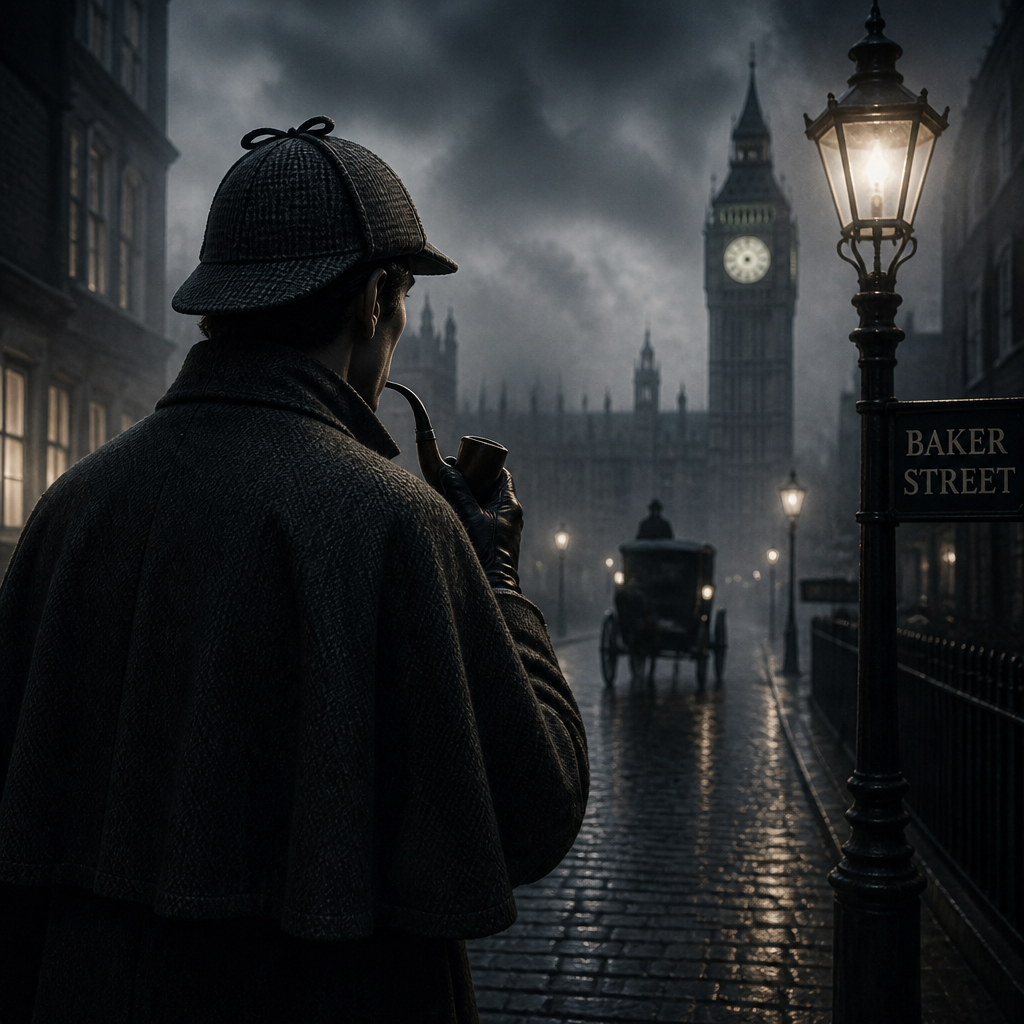

In [96]:
ask_ai("Find at most two quotes about misteries. Then generate an image to show them to me.", verbose = True)